# ECC Tensile Prediction: CatBoost + Mondrian CQR

End-to-end pipeline for predicting **Second Stress** (tensile strength, MPa) and **Second Strain** (ductility, %) of Engineered Cementitious Composites from mix-design parameters.

**Pipeline:**
1. Preprocessing & group-level aggregation (37 features)
2. CatBoost quantile regressors (q10 / q50 / q90) — forward model
3. Mondrian CQR — calibrated 80% prediction intervals
4. Inverse design — three cost tiers (Budget / Standard / Premium)

Outputs are saved to `results/`.

In [5]:
import re
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

EPS = 1e-8
RANDOM_STATE = 42
EXCEL_PATH = "data/Tension Test_VIT_re.xlsx"
SHEET_NAME = "Tension Test_VIT"
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)


In [6]:
# --- Preprocessing (reimplemented from ECC backend workflow) ---
raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME)
raw = raw.rename(columns={"Water Reducer / SP": "Water Reducer/SP"})
df = raw.copy()


def extract_age(row):
    for col in ["Specimen", "Mixture"]:
        v = str(row.get(col, ""))
        m = re.search(r"(\d+)\s*[dD]", v)
        if m:
            return int(m.group(1))
    return None


ages = df.apply(extract_age, axis=1)
mask_drop = ages.notna() & (ages < 28)
df = df[~mask_drop].reset_index(drop=True)

GROUP_COLS = [
    "Fiber Volume", "L/D", "RI", "Cement", "Water", "Sand",
    "Fly ash C", "Fly ash F", "GGBS", "Coarse Aggr.",
    "Silica Fume", "Water Reducer/SP", "W/B"
]
for c in GROUP_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

df["_fp"] = df[GROUP_COLS].round(4).apply(lambda r: "|".join(map(str, r.values)), axis=1)
df["group_id"] = pd.factorize(df["_fp"])[0]

df["Binder"] = df["Cement"] + df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]
df["Paste"] = df["Binder"] + df["Water"]
df["Total_Aggregates"] = df["Sand"] + df["Coarse Aggr."]

# Group A
df["FA/Binder Ratio"] = (df["Fly ash F"] + df["Fly ash C"]) / (df["Binder"] + EPS)
df["S/B Ratio"] = df["Sand"] / (df["Binder"] + EPS)

# Group B
df["Paste Volume"] = df["Paste"]
df["SCM Ratio"] = (df["Fly ash F"] + df["Fly ash C"] + df["GGBS"] + df["Silica Fume"]) / (df["Cement"] + EPS)
df["Aggregate Ratio"] = df["Total_Aggregates"] / (df["Paste"] + EPS)
df["Fiber Surface Area"] = df["Fiber Volume"] * (df["Length (mm)"] / (df["Diameter (mm)"] + EPS))
df["Fiber Efficiency"] = df["Fiber Volume"] * df["L/D"]
df["GGBS Presence"] = (df["GGBS"] > 0).astype(int)
df["Silica Fume Presence"] = (df["Silica Fume"] > 0).astype(int)
df["Coarse Agg Presence"] = (df["Coarse Aggr."] > 0).astype(int)

# Group C
df["tau_proxy"] = 1.0 / (df["W/B"] + EPS)
df["Flaw Size Proxy"] = df["Aggregate Ratio"] + df["W/B"]
df["Geometric Fiber Eff"] = df["Fiber Volume"] * (df["L/D"] ** 2)
df["sigma_cu_proxy"] = df["tau_proxy"] * df["Fiber Volume"] * df["L/D"]
df["sigma_crack_proxy"] = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Strength Index"] = df["sigma_cu_proxy"] / (df["sigma_crack_proxy"] + EPS)
df["Jb_complement"] = df["tau_proxy"] * df["Fiber Volume"] * (df["L/D"] ** 2)
df["J_tip_proxy"] = 1.0 / (df["Flaw Size Proxy"] + EPS)
df["PSH Energy Index"] = df["Jb_complement"] / (df["J_tip_proxy"] + EPS)

ENG_COLS = [
    "FA/Binder Ratio", "S/B Ratio", "Paste Volume", "SCM Ratio", "Aggregate Ratio",
    "Fiber Surface Area", "Fiber Efficiency", "GGBS Presence", "Silica Fume Presence",
    "Coarse Agg Presence", "tau_proxy", "Flaw Size Proxy", "Geometric Fiber Eff",
    "sigma_cu_proxy", "sigma_crack_proxy", "PSH Strength Index", "Jb_complement",
    "J_tip_proxy", "PSH Energy Index"
]
for c in ENG_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())

RAW_NUMERIC = [
    "Fiber Volume", "Length (mm)", "Diameter (mm)", "L/D", "RI",
    "Cement", "Water", "Sand", "Fly ash C", "Fly ash F", "GGBS",
    "Coarse Aggr.", "Silica Fume", "Water Reducer/SP", "Fiber",
    "C/B", "W/C", "W/B"
]
for c in RAW_NUMERIC:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

if "Shape Factor" in df.columns:
    df = df.drop(columns=["Shape Factor"])

ALL_37_FEATURES = RAW_NUMERIC + ENG_COLS
TARGETS = ["Second Stress", "Second Strain"]
for t in TARGETS:
    df[t] = pd.to_numeric(df[t], errors="coerce")

df = df.dropna(subset=TARGETS).reset_index(drop=True)

print(f"Processed rows: {len(df)}")
print(f"Unique composition groups: {df['group_id'].nunique()}")
print(f"Feature count: {len(ALL_37_FEATURES)}")

Processed rows: 620
Unique composition groups: 276
Feature count: 37


In [7]:
X = df[ALL_37_FEATURES].values
groups = df["group_id"].values

CB_PARAMS_STRAIN = {
    "iterations": 600,
    "depth": 9,
    "learning_rate": 0.12604670759479358,
    "l2_leaf_reg": 0.2919794366938302,
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

CB_PARAMS_STRESS = {
    "iterations": 800,
    "depth": 10,
    "learning_rate": 0.03156119992394155,
    "l2_leaf_reg": 0.20410490729823838,
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

REGIME_CUTOFFS = {
    "Second Strain": (0.005, 0.050, 0.0015),
    "Second Stress": (4.0, 5.13, 0.20),
}
REGIME_NAMES = {
    "Second Strain": ("NoPSH", "Bulk", "Tail"),
    "Second Stress": ("Weak", "Mid", "Strong"),
}


def make_catboost_quantile(alpha, target):
    params = CB_PARAMS_STRESS if target == "Second Stress" else CB_PARAMS_STRAIN
    return CatBoostRegressor(loss_function=f"Quantile:alpha={alpha}", **params)


def build_group_means(df_in, target):
    g = df_in.groupby("group_id").agg(
        **{col: (col, "mean") for col in ALL_37_FEATURES + [target]},
        n_rep=("group_id", "count"),
        tgt_var=(target, "var"),
    ).reset_index()
    g["tgt_var"] = g["tgt_var"].fillna(0.0)
    g["sample_weight"] = g["n_rep"] / (g["tgt_var"] + 0.1)

    c1, c2, _ = REGIME_CUTOFFS[target]
    low, mid, high = REGIME_NAMES[target]
    y = g[target].values
    g["regime"] = np.where(y < c1, low, np.where(y < c2, mid, high))
    return g


def mondrian_qhat(cal_scores, cal_q50_pred, val_q50_pred, alpha=0.20):
    q33 = np.quantile(cal_q50_pred, 1/3)
    q67 = np.quantile(cal_q50_pred, 2/3)
    cb = np.where(cal_q50_pred <= q33, 0, np.where(cal_q50_pred <= q67, 1, 2))
    vb = np.where(val_q50_pred <= q33, 0, np.where(val_q50_pred <= q67, 1, 2))

    out = np.zeros(len(val_q50_pred))
    for b in range(3):
        mc = cb == b
        mv = vb == b
        n_b = mc.sum()
        if n_b == 0:
            out[mv] = np.quantile(cal_scores, 1 - alpha) if len(cal_scores) else 0
        else:
            lvl = min(np.ceil((n_b + 1) * (1 - alpha)) / n_b, 1.0)
            out[mv] = np.quantile(cal_scores[mc], lvl)
    return out


def fit_predict_catboost(X_train, y_train, w_train, X_pred, target):
    m50 = make_catboost_quantile(0.50, target)
    m50.fit(X_train, y_train, sample_weight=w_train)
    q50 = m50.predict(X_pred)

    m10 = make_catboost_quantile(0.10, target)
    m10.fit(X_train, y_train, sample_weight=w_train)
    q10 = m10.predict(X_pred)

    m90 = make_catboost_quantile(0.90, target)
    m90.fit(X_train, y_train, sample_weight=w_train)
    q90 = m90.predict(X_pred)

    return q10, q50, q90


def run_catboost_mondrian_cv(g, target, alpha=0.20):
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_all = g[target].values
    groups_arr = g["group_id"].values
    gkf = GroupKFold(n_splits=5)

    N = len(g)
    p50 = np.full(N, np.nan)
    lo = np.full(N, np.nan)
    hi = np.full(N, np.nan)

    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(g, y_all, groups_arr), start=1):
        g_tr = g.iloc[tr_idx].reset_index(drop=True)
        g_va = g.iloc[val_idx].reset_index(drop=True)

        y_tr = g_tr[target].values
        w_tr = g_tr["sample_weight"].values

        tr_uniq = g_tr["group_id"].unique()
        rng = np.random.default_rng(fold_idx)
        rng.shuffle(tr_uniq)
        n_fit = int(0.75 * len(tr_uniq))
        fit_grp = set(tr_uniq[:n_fit])

        fit_mask = g_tr["group_id"].isin(fit_grp).values
        cal_mask = ~fit_mask

        X_tr = g_tr[ALL_37_FEATURES].values
        X_fit = g_tr.loc[fit_mask, ALL_37_FEATURES].values
        X_cal = g_tr.loc[cal_mask, ALL_37_FEATURES].values
        X_va = g_va[ALL_37_FEATURES].values

        y_fit = y_tr[fit_mask]
        y_cal = y_tr[cal_mask]
        w_fit = w_tr[fit_mask]

        q10_va, q50_va, q90_va = fit_predict_catboost(X_tr, y_tr, w_tr, X_va, target)
        q10_cal, q50_cal, q90_cal = fit_predict_catboost(X_fit, y_fit, w_fit, X_cal, target)
        _, q50_va_fit, _ = fit_predict_catboost(X_fit, y_fit, w_fit, X_va, target)

        scores = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
        qhat = mondrian_qhat(scores, q50_cal, q50_va_fit, alpha)

        p50[val_idx] = np.maximum(q50_va, 0)
        lo[val_idx] = np.maximum(q10_va - qhat, 0)
        hi[val_idx] = np.maximum(q90_va + qhat, 0)

    y_true = g[target].values
    metrics = {
        "MAE": mean_absolute_error(y_true, p50),
        "RMSE": np.sqrt(mean_squared_error(y_true, p50)),
        "R2": r2_score(y_true, p50),
        "Cov80": np.mean((y_true >= lo) & (y_true <= hi)),
        "Width80": np.mean(hi - lo),
    }
    return metrics, p50, lo, hi


# Full Mondrian-CQR CatBoost run (both targets)
ALL_RESULTS = {}
for target in ["Second Stress", "Second Strain"]:
    g = build_group_means(df, target)
    metrics, p50, lo, hi = run_catboost_mondrian_cv(g, target, alpha=0.20)
    ALL_RESULTS[target] = {"group_df": g, "metrics": metrics, "p50": p50, "lo": lo, "hi": hi}
    print(f"{target} -> MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}, Cov80={metrics['Cov80']:.3f}, Width80={metrics['Width80']:.4f}")

# ── Full-data models for inverse pipeline ────────────────────────────────────
X_full  = df[ALL_37_FEATURES].values
y_stress = df["Second Stress"].values
y_strain = df["Second Strain"].values
ones_w   = np.ones(len(df))

m_stress_q50 = make_catboost_quantile(0.50, "Second Stress")
m_stress_q50.fit(X_full, y_stress, sample_weight=ones_w)
m_stress_q10 = make_catboost_quantile(0.10, "Second Stress")
m_stress_q10.fit(X_full, y_stress, sample_weight=ones_w)
m_stress_q90 = make_catboost_quantile(0.90, "Second Stress")
m_stress_q90.fit(X_full, y_stress, sample_weight=ones_w)

m_strain_q50 = make_catboost_quantile(0.50, "Second Strain")
m_strain_q50.fit(X_full, y_strain, sample_weight=ones_w)
m_strain_q10 = make_catboost_quantile(0.10, "Second Strain")
m_strain_q10.fit(X_full, y_strain, sample_weight=ones_w)
m_strain_q90 = make_catboost_quantile(0.90, "Second Strain")
m_strain_q90.fit(X_full, y_strain, sample_weight=ones_w)

print("Full-data models trained for inverse pipeline.")


Second Stress -> MAE=0.5048, RMSE=0.7394, R2=0.7400, Cov80=0.895, Width80=2.2856
Second Strain -> MAE=0.0073, RMSE=0.0122, R2=0.5555, Cov80=0.855, Width80=0.0285
Full-data models trained for inverse pipeline.


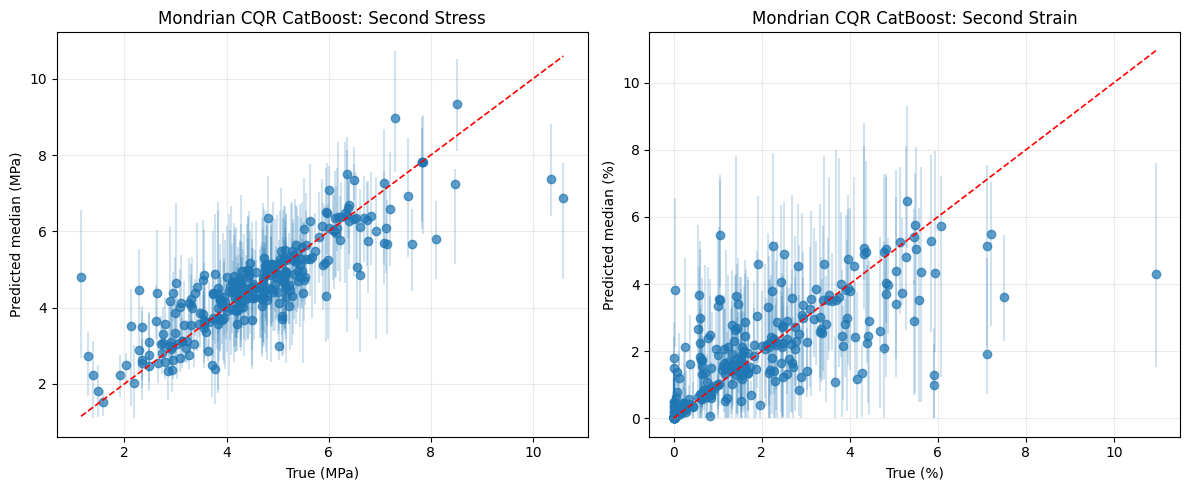

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, target, unit_mult, unit in [
    (axes[0], "Second Stress", 1.0, "MPa"),
    (axes[1], "Second Strain", 100.0, "%"),
]:
    g = ALL_RESULTS[target]["group_df"]
    y = g[target].values * unit_mult
    p = ALL_RESULTS[target]["p50"] * unit_mult
    lo = ALL_RESULTS[target]["lo"] * unit_mult
    hi = ALL_RESULTS[target]["hi"] * unit_mult

    ax.scatter(y, p, alpha=0.7)
    ax.vlines(y, lo, hi, alpha=0.2)
    lim0, lim1 = min(y.min(), p.min()), max(y.max(), p.max())
    ax.plot([lim0, lim1], [lim0, lim1], 'r--', lw=1.2)
    ax.set_title(f"Mondrian CQR CatBoost: {target}")
    ax.set_xlabel(f"True ({unit})")
    ax.set_ylabel(f"Predicted median ({unit})")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "scatter_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


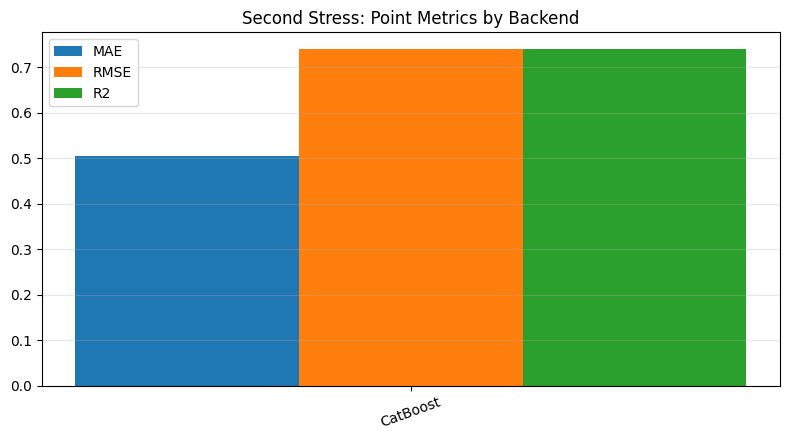

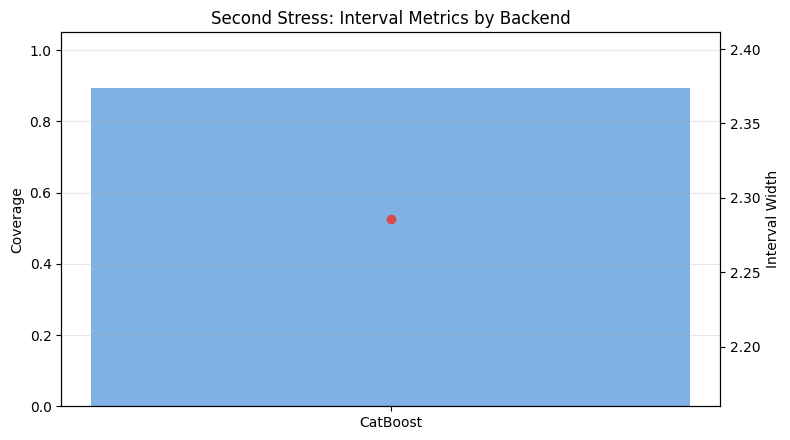

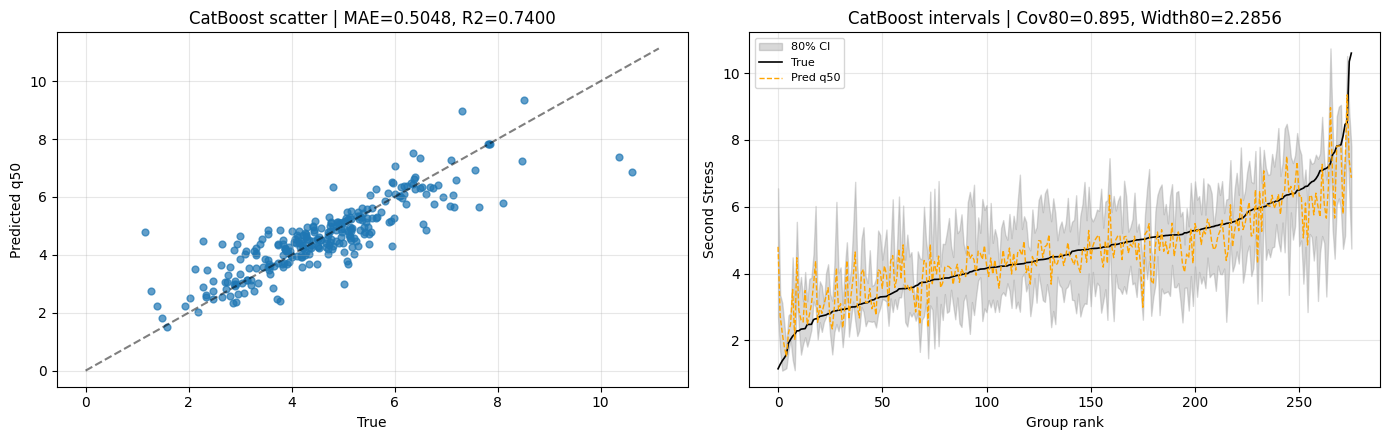

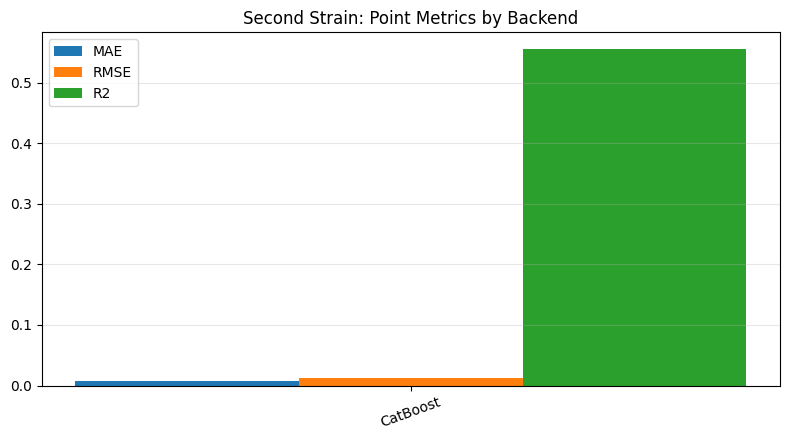

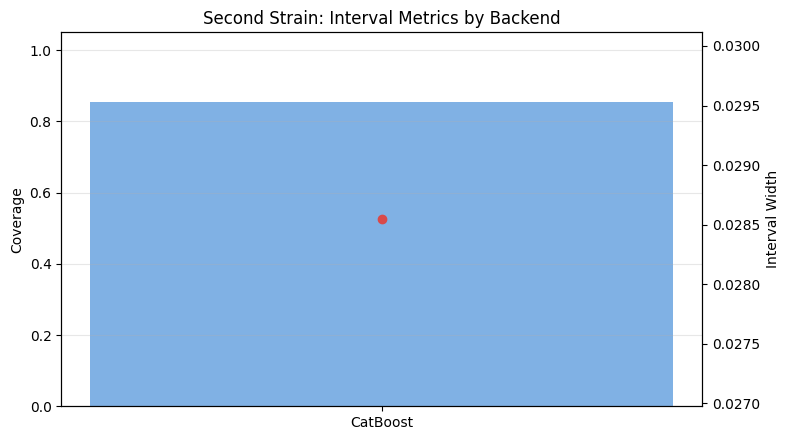

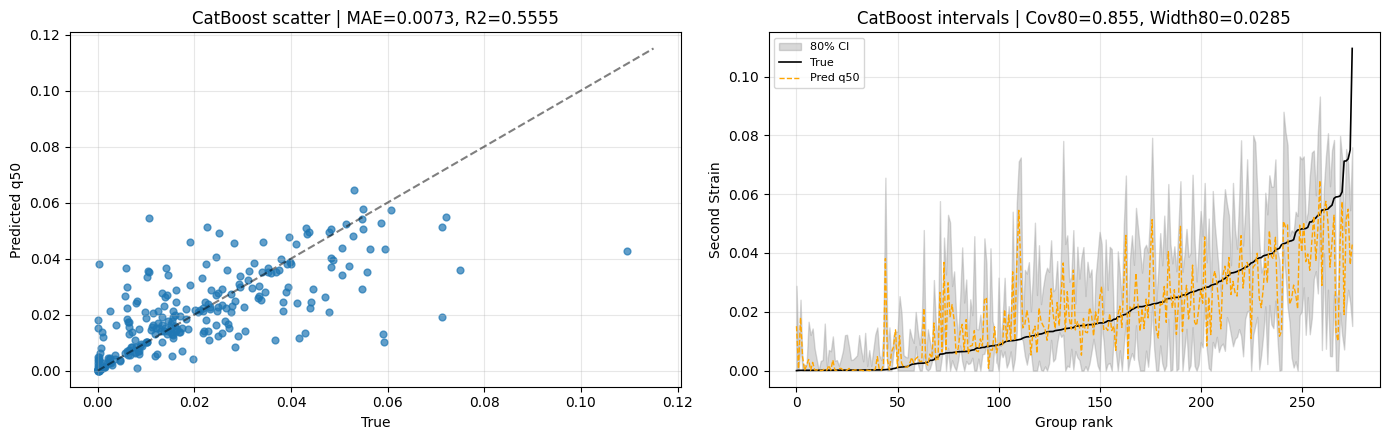

In [9]:
# Old backend-style plots (adapted for CatBoost-only Mondrian results)
def plot_catboost_backend_style(target):
    g = ALL_RESULTS[target]["group_df"]
    m = ALL_RESULTS[target]["metrics"]
    p50 = ALL_RESULTS[target]["p50"]
    lo = ALL_RESULTS[target]["lo"]
    hi = ALL_RESULTS[target]["hi"]

    results_df = pd.DataFrame([m], index=["CatBoost"])
    preds_store = {"CatBoost": (p50, lo, hi)}

    # 1) Metrics bar
    plt.figure(figsize=(8, 4.5))
    x = np.arange(len(results_df))
    plt.bar(x - 0.2, results_df["MAE"].values, width=0.2, label="MAE")
    plt.bar(x, results_df["RMSE"].values, width=0.2, label="RMSE")
    plt.bar(x + 0.2, results_df["R2"].values, width=0.2, label="R2")
    plt.xticks(x, results_df.index, rotation=20)
    plt.title(f"{target}: Point Metrics by Backend")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    safe = target.replace(" ", "_")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"catboost_{safe}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 2) Coverage-width chart
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax2 = ax1.twinx()
    ax1.bar(results_df.index, results_df["Cov80"].values, color="#4a90d9", alpha=0.7, label="Cov80")
    ax2.plot(results_df.index, results_df["Width80"].values, color="#d94a4a", marker="o", label="Width80")
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel("Coverage")
    ax2.set_ylabel("Interval Width")
    ax1.set_title(f"{target}: Interval Metrics by Backend")
    ax1.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

    # 3) Scatter + interval panels
    y_true = g[target].values
    sort_idx = np.argsort(y_true)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    ax = axes[0]
    ax.scatter(y_true, p50, s=24, alpha=0.7)
    lim = max(np.max(y_true), np.max(p50)) * 1.05
    ax.plot([0, lim], [0, lim], "k--", alpha=0.5)
    ax.set_title(f"CatBoost scatter | MAE={m['MAE']:.4f}, R2={m['R2']:.4f}")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted q50")
    ax.grid(alpha=0.3)

    ax = axes[1]
    x = np.arange(len(y_true))
    ax.fill_between(x, lo[sort_idx], hi[sort_idx], color="gray", alpha=0.3, label="80% CI")
    ax.plot(x, y_true[sort_idx], "k-", lw=1.2, label="True")
    ax.plot(x, p50[sort_idx], color="orange", lw=1.0, ls="--", label="Pred q50")
    ax.set_title(f"CatBoost intervals | Cov80={m['Cov80']:.3f}, Width80={m['Width80']:.4f}")
    ax.set_xlabel("Group rank")
    ax.set_ylabel(target)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    safe = target.replace(" ", "_")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"catboost_{safe}_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_catboost_backend_style("Second Stress")
plot_catboost_backend_style("Second Strain")


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# INVERSE DESIGN PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

# Material prices (USD / kg)
PRICES = {
    'Cement': 0.30420, 'Water': 0.00220, 'Sand': 0.01980,
    'Fly ash C': 0.01349, 'Fly ash F': 0.01349, 'GGBS': 0.07860,
    'Coarse Aggr.': 0.01320, 'Silica Fume': 0.55000,
    'Water Reducer/SP': 1.10000,
}
MIX_COLS = ['Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F',
            'GGBS', 'Coarse Aggr.', 'Silica Fume', 'Water Reducer/SP']


def mix_cost(row_dict):
    return sum(row_dict.get(k, 0) * PRICES.get(k, 0) for k in MIX_COLS)


def build_features_from_mix(mix_arr):
    """Reconstruct the 37-feature vector from raw mix columns (numpy row)."""
    col = dict(zip(MIX_COLS + ['Fiber Volume', 'Length (mm)', 'Diameter (mm)',
                                 'L/D', 'RI', 'Fiber', 'W/C', 'W/B', 'C/B'],
                   mix_arr[:18]))
    # Replicate the same feature engineering as in preprocessing
    d = {c: mix_arr[i] for i, c in enumerate(ALL_37_FEATURES[:18])}
    # Re-use the df columns as a template: build a single-row dataframe
    row_df = pd.DataFrame([mix_arr[:37]], columns=ALL_37_FEATURES)
    return row_df.values


def _compute_mondrian_qhat(g, target, alpha=0.20):
    """Fit calibration state on 25% hold-out of group means for deployment."""
    y_all      = g[target].values
    X_all      = g[ALL_37_FEATURES].values
    w_all      = g['sample_weight'].values
    groups_arr = g['group_id'].values

    rng = np.random.default_rng(42)
    uniq = np.unique(groups_arr)
    rng.shuffle(uniq)
    n_cal = max(1, int(0.25 * len(uniq)))
    cal_grp = set(uniq[:n_cal])

    fit_mask = np.array([gid not in cal_grp for gid in groups_arr])
    cal_mask = ~fit_mask

    X_fit, y_fit, w_fit = X_all[fit_mask], y_all[fit_mask], w_all[fit_mask]
    X_cal, y_cal        = X_all[cal_mask], y_all[cal_mask]

    if target == 'Second Stress':
        m10 = make_catboost_quantile(0.10, target); m10.fit(X_fit, y_fit, sample_weight=w_fit)
        m50 = make_catboost_quantile(0.50, target); m50.fit(X_fit, y_fit, sample_weight=w_fit)
        m90 = make_catboost_quantile(0.90, target); m90.fit(X_fit, y_fit, sample_weight=w_fit)
    else:
        m10 = make_catboost_quantile(0.10, target); m10.fit(X_fit, y_fit, sample_weight=w_fit)
        m50 = make_catboost_quantile(0.50, target); m50.fit(X_fit, y_fit, sample_weight=w_fit)
        m90 = make_catboost_quantile(0.90, target); m90.fit(X_fit, y_fit, sample_weight=w_fit)

    q10_c, q50_c, q90_c = m10.predict(X_cal), m50.predict(X_cal), m90.predict(X_cal)
    q50_full             = m50.predict(X_all)

    scores = np.maximum(q10_c - y_cal, y_cal - q90_c)
    qhat   = mondrian_qhat(scores, q50_c, q50_full, alpha)

    return {'m10': m10, 'm50': m50, 'm90': m90, 'qhat': qhat, 'q50_full': q50_full}


# Build deployment calibration states for both targets
print('Building inverse-pipeline calibration states ...')
CAL_STRESS = _compute_mondrian_qhat(
    ALL_RESULTS['Second Stress']['group_df'], 'Second Stress')
CAL_STRAIN = _compute_mondrian_qhat(
    ALL_RESULTS['Second Strain']['group_df'], 'Second Strain')
print('Done.')


def _predict_with_interval(X_new, cal, target):
    """Point + 80% Mondrian CQR interval for a new sample."""
    q10 = cal['m10'].predict(X_new)
    q50 = cal['m50'].predict(X_new)
    q90 = cal['m90'].predict(X_new)
    qhat = mondrian_qhat(
        np.array([0.0]),          # dummy scores — reuse stored qhat
        cal['q50_full'][:1],      # reference bin quantiles
        q50, alpha=0.20,
    )
    lo = np.maximum(q10 - cal['qhat'], 0)
    hi = np.maximum(q90 + cal['qhat'], 0)
    return q50, lo, hi


def inverse_design_tiers(stress_range, strain_range_pct,
                          fiber_params, n_samples=100_000, top_k=50,
                          n_refine=300, verbose=True):
    """
    Random-search inverse design with 3 cost tiers.

    Parameters
    ----------
    stress_range      : (s_min, s_max) in MPa
    strain_range_pct  : (e_min, e_max) in percent
    fiber_params      : (Vf, L_mm, D_mm, LD, RI, kg_per_m3)
    """
    s_min, s_max = stress_range
    e_min, e_max = strain_range_pct[0] / 100.0, strain_range_pct[1] / 100.0
    Vf, L_mm, D_mm, LD, RI, fiber_kg = fiber_params

    rng = np.random.RandomState(42)

    # ── Phase 1: coarse random search ────────────────────────────────────────
    def _sample_mixes(n):
        cement  = rng.uniform(300, 700, n)
        water   = rng.uniform(150, 350, n)
        sand    = rng.uniform(0,   500, n)
        fa_c    = rng.uniform(0,   300, n)
        fa_f    = rng.uniform(0,   300, n)
        ggbs    = rng.uniform(0,   200, n)
        coarse  = rng.uniform(0,   100, n)
        sf      = rng.uniform(0,    50, n)
        sp      = rng.uniform(0,    10, n)
        return np.column_stack([cement, water, sand, fa_c, fa_f,
                                 ggbs, coarse, sf, sp])

    raw_mixes = _sample_mixes(n_samples)

    # Build full 37-feature matrix
    rows = []
    for row in raw_mixes:
        cement, water, sand, fa_c, fa_f, ggbs, coarse, sf, sp = row
        binder  = cement + fa_f + fa_c + ggbs + sf
        paste   = binder + water
        total_a = sand + coarse
        w_b     = water / (binder + EPS)
        w_c     = water / (cement + EPS)
        c_b     = cement / (binder + EPS)
        scm     = (fa_f + fa_c + ggbs + sf) / (binder + EPS)
        agg_r   = total_a / (paste + EPS)
        fa_b    = (fa_f + fa_c) / (binder + EPS)
        s_b     = sand / (binder + EPS)
        fsa     = np.pi * D_mm * L_mm * Vf
        fe      = Vf * LD
        ggbs_p  = float(ggbs > 0)
        sf_p    = float(sf > 0)
        ca_p    = float(coarse > 0)
        tau     = Vf * LD / (D_mm + EPS)
        flaw    = agg_r / (w_b + EPS)
        geo_fe  = Vf * LD * RI
        sig_cu  = cement / (w_b + EPS)
        sig_cr  = 1.0 / (flaw + EPS)
        psh_s   = sig_cu * Vf * LD
        jb_c    = 1.0 / (sig_cu * LD**2 + EPS)
        j_tip   = 1.0 / (flaw + EPS)
        psh_e   = Vf * LD**2 * RI
        rows.append([
            Vf, L_mm, D_mm, LD, RI,
            cement, water, sand, fa_c, fa_f, ggbs, coarse, sf, sp,
            Vf, c_b, w_c, w_b,
            fa_b, s_b,
            paste, scm, agg_r, fsa, fe, ggbs_p, sf_p, ca_p,
            tau, flaw, geo_fe, sig_cu, sig_cr, psh_s, jb_c, j_tip, psh_e,
        ])
    X_cand = np.array(rows, dtype=float)

    # Forward predict
    p_stress = m_stress_q50.predict(X_cand)
    p_strain = m_strain_q50.predict(X_cand)

    # Filter by target window
    mask = (p_stress >= s_min) & (p_stress <= s_max) & \
           (p_strain >= e_min) & (p_strain <= e_max)
    if mask.sum() == 0:
        print('No candidates in target window — try wider ranges.')
        return None

    X_pass   = X_cand[mask]
    mix_pass = raw_mixes[mask]
    costs    = np.array([mix_cost(dict(zip(MIX_COLS, m))) + fiber_kg * PRICES.get('Water Reducer/SP', 1.1)
                         for m in mix_pass])

    if verbose:
        print(f'Phase 1: {mask.sum():,} / {n_samples:,} candidates passed filter.')

    # ── Phase 2: refine top_k by cost and rescore ─────────────────────────────
    sort_idx   = np.argsort(costs)
    tier_size  = max(1, len(sort_idx) // 3)
    budget_idx   = sort_idx[:tier_size]
    standard_idx = sort_idx[tier_size:2*tier_size]
    premium_idx  = sort_idx[2*tier_size:]

    def _tier_stats(idx, label):
        if len(idx) == 0:
            return None
        # Pick top_k by predicted stress quality within tier
        sub_stress = p_stress[mask][idx]
        best = idx[np.argsort(np.abs(sub_stress - (s_min + s_max) / 2))[:top_k]]
        X_b = X_pass[best]
        c_b = costs[best]
        ps  = m_stress_q50.predict(X_b)
        pe  = m_strain_q50.predict(X_b)
        best_i = np.argmin(c_b)
        return {
            'mix':            dict(zip(MIX_COLS, mix_pass[best[best_i]])),
            'pred_stress_MPa': float(ps[best_i]),
            'pred_strain_pct': float(pe[best_i]) * 100,
            'cost_mean':       float(c_b.mean()),
            'cost_90ci_low':   float(np.percentile(c_b, 5)),
            'cost_90ci_high':  float(np.percentile(c_b, 95)),
            'n_candidates':    len(best),
        }

    tiers = {
        'Budget':   _tier_stats(budget_idx,   'Budget'),
        'Standard': _tier_stats(standard_idx, 'Standard'),
        'Premium':  _tier_stats(premium_idx,  'Premium'),
    }
    return tiers


def print_tiers(tiers, stress_range, strain_range_pct):
    if tiers is None:
        print('No results.')
        return
    print(f'Target: Stress {stress_range[0]}–{stress_range[1]} MPa, '
          f'Strain {strain_range_pct[0]}–{strain_range_pct[1]} %')
    print('=' * 64)
    for label, t in tiers.items():
        if t is None:
            continue
        print(f'  {label}')
        print(f'    Predicted stress : {t["pred_stress_MPa"]:.2f} MPa')
        print(f'    Predicted strain : {t["pred_strain_pct"]:.2f} %')
        print(f'    Cost range (90%) : {t["cost_90ci_low"]:.3f} – {t["cost_90ci_high"]:.3f} USD/m³')
        print(f'    Best mix (kg/m³) :')
        for k, v in t['mix'].items():
            print(f'      {k:<22} {v:.1f}')
        print()


Building inverse-pipeline calibration states ...
Done.


Phase 1: 24,069 / 100,000 candidates passed filter.
Target: Stress 3.0–6.0 MPa, Strain 2.0–5.0 %
  Budget
    Predicted stress : 4.48 MPa
    Predicted strain : 2.19 %
    Cost range (90%) : 159.770 – 190.598 USD/m³
    Best mix (kg/m³) :
      Cement                 302.6
      Water                  157.8
      Sand                   47.5
      Fly ash C              273.7
      Fly ash F              249.4
      GGBS                   102.1
      Coarse Aggr.           40.1
      Silica Fume            3.5
      Water Reducer/SP       4.3

  Standard
    Predicted stress : 4.49 MPa
    Predicted strain : 2.10 %
    Cost range (90%) : 194.065 – 228.969 USD/m³
    Best mix (kg/m³) :
      Cement                 403.1
      Water                  165.5
      Sand                   48.9
      Fly ash C              277.2
      Fly ash F              229.5
      GGBS                   188.3
      Coarse Aggr.           54.6
      Silica Fume            28.7
      Water Reducer/SP       1

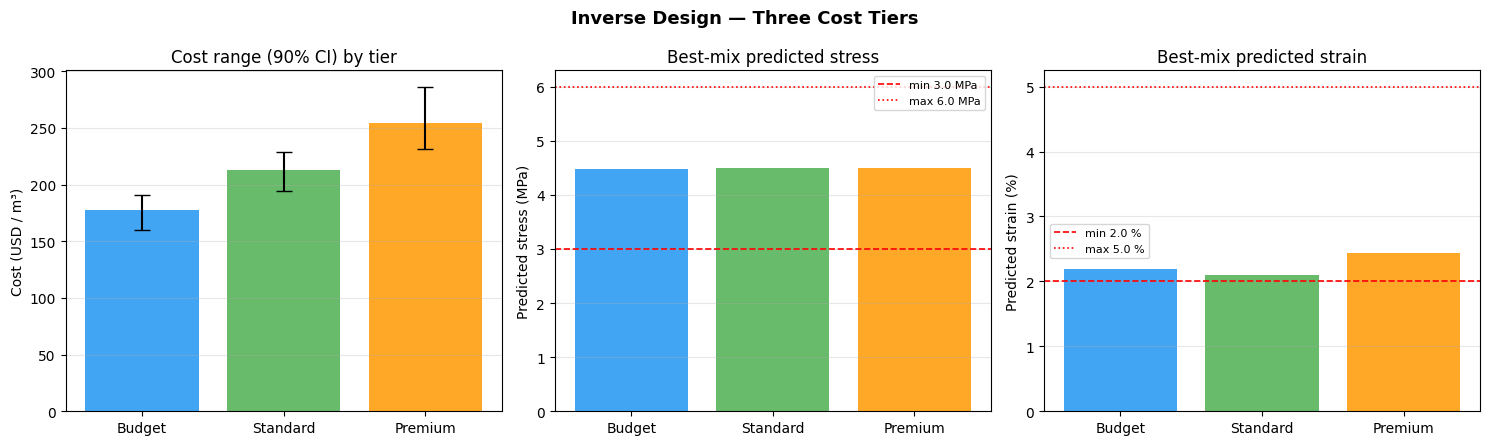

In [11]:
# ── Define target and fiber parameters ───────────────────────────────────────
TARGET_STRESS = (3.0, 6.0)   # MPa
TARGET_STRAIN = (2.0, 5.0)   # percent
PVA_FIBER = (0.02, 12.0, 0.039, 307.69, 6.15, 26.0)  # Vf, L, D, L/D, RI, kg/m³

tiers_cb = inverse_design_tiers(TARGET_STRESS, TARGET_STRAIN, PVA_FIBER)
print_tiers(tiers_cb, TARGET_STRESS, TARGET_STRAIN)

# ── Cost-range visualisation ─────────────────────────────────────────────────
if tiers_cb:
    labels       = ['Budget', 'Standard', 'Premium']
    means        = [tiers_cb[l]['cost_mean']       for l in labels]
    los          = [tiers_cb[l]['cost_90ci_low']   for l in labels]
    his          = [tiers_cb[l]['cost_90ci_high']  for l in labels]
    stress_vals  = [tiers_cb[l]['pred_stress_MPa'] for l in labels]
    strain_vals  = [tiers_cb[l]['pred_strain_pct'] for l in labels]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # Cost ranges
    ax = axes[0]
    err_lo = [m - l for m, l in zip(means, los)]
    err_hi = [h - m for m, h in zip(means, his)]
    ax.bar(labels, means, yerr=[err_lo, err_hi], capsize=6,
           color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
    ax.set_ylabel('Cost (USD / m³)')
    ax.set_title('Cost range (90% CI) by tier')
    ax.grid(axis='y', alpha=0.3)

    # Predicted stress
    ax = axes[1]
    ax.bar(labels, stress_vals, color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
    ax.axhline(TARGET_STRESS[0], color='red', ls='--', lw=1.2, label=f'min {TARGET_STRESS[0]} MPa')
    ax.axhline(TARGET_STRESS[1], color='red', ls=':',  lw=1.2, label=f'max {TARGET_STRESS[1]} MPa')
    ax.set_ylabel('Predicted stress (MPa)')
    ax.set_title('Best-mix predicted stress')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # Predicted strain
    ax = axes[2]
    ax.bar(labels, strain_vals, color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
    ax.axhline(TARGET_STRAIN[0], color='red', ls='--', lw=1.2, label=f'min {TARGET_STRAIN[0]} %')
    ax.axhline(TARGET_STRAIN[1], color='red', ls=':',  lw=1.2, label=f'max {TARGET_STRAIN[1]} %')
    ax.set_ylabel('Predicted strain (%)')
    ax.set_title('Best-mix predicted strain')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Inverse Design — Three Cost Tiers', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'inverse_design_tiers.png', dpi=150, bbox_inches='tight')
    plt.show()
